In [1]:
# Antes de correr este archivo, renombrar los videos usando "Rename czi files.ipynb"

# Importo librerías necesarias
from ipynb.fs.defs.aux_functions import *

from ipywidgets import interact, interact_manual, interactive, fixed
from IPython.display import display
import pandas as pd

from os.path import exists
from PIL import Image

c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\tensorflow\python\framework\dtypes.

In [2]:
areas_dir = r'C:\Users\PC\Documents\GitHub\social_isolation_habenula_imaging\Exp_25\PKL 06-2025'
# areas_dir = r'C:\Users\PC\Desktop\Analisis conf\PKL 11-2024'
areas = load_areas(areas_dir)

for key in areas:
    print(key + ":", len(areas[key].trials), "trials.")

113-1: 10 trials.
114-1: 10 trials.
115-1: 10 trials.
116-1: 10 trials.
117-1: 10 trials.
118-1: 10 trials.
120-1: 10 trials.
121-1: 10 trials.
122-1: 10 trials.
123-1: 10 trials.
124-1: 10 trials.
125-1: 10 trials.
126-1: 10 trials.
127-1: 10 trials.
129-1: 10 trials.
130-1: 10 trials.
131-1: 10 trials.
132-1: 10 trials.
133-1: 10 trials.
134-1: 10 trials.
135-1: 10 trials.
136-1: 10 trials.
137-1: 10 trials.
138-1: 10 trials.
139-1: 10 trials.
143-1: 10 trials.


In [3]:
disk_dir = r"C:\Users\PC\My Drive\Violeta"

os.chdir(disk_dir)  
dataset_2 = pd.read_excel("HabenulaPosta.xlsx")

In [4]:
for key in areas:
    areas[key].edad = areas[key].trials[0].data['Edad']
    areas[key].n_un_hb = len(areas[key].trials[0].roi_activities['Hb'])
    areas[key].aislado = list(dataset_2['aislado'][dataset_2['animal']==int(key[:-2])])[0]

``` python
def to_dffs(activities, time_scale_in_frames = 15, window = 10, fast = False):
    baseline = linearly_extended_filter(activities, time_scale_in_frames, window = window, fast = fast)
    #baseline = gaussian_filter1d(activities, time_scale_in_frames, mode = 'nearest')
    
    dffs = (activities - baseline)#/baseline
    return dffs, baseline


def linearly_extended_filter(a, scale, window = 0, fast = False):
    baseline = np.zeros(a.shape)
    
    for i in range(len(a)):
        baseline[i] = linearly_extended_filter_solo(a[i], scale, window = window, fast = fast)
        
    return baseline


def linearly_extended_filter_solo(a, scale, window = 0, fast = False):
    if window == 0 or window > len(a):
        window = int(len(a)/2)
    
    init_window = a[:window]
    final_window = a[-window:]
    
    new_length = len(init_window) + len(a) + len(final_window)
    extended = np.zeros((new_length,))
    
    if fast:
        extended[:window] = a[:window] - (a[window:window+3].mean() - a[0:3].mean())
        extended[window:-window] = a
        extended[-window:] = a[-window:] + (a[-4:-1].mean() - a[-window-3:-window].mean())
    else:
        reg_init = LinearRegression().fit(np.arange(len(init_window)).reshape(-1, 1), init_window)
        reg_final = LinearRegression().fit(np.arange(len(final_window)).reshape(-1, 1), final_window)

        extended[:window] = reg_init.predict(np.arange(-window, 0).reshape(-1,1))
        extended[window:-window] = a
        extended[-window:] = reg_final.predict(np.arange(len(final_window), len(final_window) + window).reshape(-1,1))
    
    filtered = gaussian_filter1d(extended, scale, mode = 'nearest')
    
    return filtered[window:-window] '```

In [6]:
# import numpy as np
from scipy.signal import savgol_filter, medfilt
from scipy.ndimage import percentile_filter
# import matplotlib.pyplot as plt
from pykalman import KalmanFilter
import pywt
# from filterpy.kalman import KalmanFilter


def kalman_denoise(data):
    # Initialize the Kalman filter
    kf = KalmanFilter(transition_matrices = [1],
                      observation_matrices = [1],
                      initial_state_mean = data[0],
                      initial_state_covariance = 1,
                      observation_covariance=0.1,
                      transition_covariance=0.1)
    
    # Use the Kalman filter to estimate the hidden state
    return kf.smooth(data)[0].flatten()

def past_percentile_filter(data, percentile, size):
    output = np.empty_like(data)
    for i in range(len(data)):
        if i < size:
            # For the initial elements, we still need to consider some "future" elements
            output[i] = np.percentile(data[:i+size+1], percentile)
        else:
            output[i] = np.percentile(data[i-size:i+1], percentile)
    return output

def to_dffs(activities, baseline_window=60, percentile=8):
    # Calculate a rolling baseline using a percentile filter
    baselines = np.empty_like(activities)
    for i in range(activities.shape[0]):
        #baselines[i, :] = percentile_filter(activities[i, :], percentile, size=baseline_window)
        baselines[i, :] = past_percentile_filter(activities[i, :], percentile, size=baseline_window)

    # Ensure the baseline is not zero to avoid division by zero
    baselines = np.where(baselines==0, np.finfo(float).eps, baselines)

    # Calculate dF/F
    dffs = (activities - baselines) / baselines

    return dffs, baselines

def to_binaries(dffs, smooth_window=5, polyorder=3, multiplier=3):
    # Smooth the dF/F signal using a Savitzky-Golay filter
    smooth_dffs = np.empty_like(dffs)
    
    for i in range(dffs.shape[0]):
    #    smooth_dffs[i, :] = savgol_filter(dffs[i, :], smooth_window, polyorder)
        smooth_dffs[i, :] = kalman_denoise(dffs[i, :])
    #    smooth_dffs[i, :] = wavelet_denoise(dffs[i, :])
        
    # Calculate the noise level using the median absolute deviation
    mad = np.median(np.abs(smooth_dffs - np.median(smooth_dffs, axis=1, keepdims=True)), axis=1, keepdims=True)

    # Threshold for event detection
    threshold = np.median(smooth_dffs, axis=1, keepdims=True) + multiplier * mad

    # A neuron is active if the dF/F signal exceeds the threshold
    binaries = smooth_dffs > threshold

    return binaries, smooth_dffs

In [11]:
import dask.bag as db

# Adjust these values based on your system's resources
num_workers = 10 # Set the number of workers
client = Client(n_workers=num_workers)

def process_trial(trial):
    print("Processing trial number", trial.trial)

    trial.roi_dffs_rea = {}
    trial.roi_baselines_rea = {}
    trial.roi_binaries_rea = {}
    trial.roi_smooth_dffs_rea = {}
    
    for subarea in trial.roi_activities:
        activities = trial.roi_activities[subarea]

        if activities.shape[0] == 0:
            print("No neurons in this region... weird.", trial.trial, subarea)
            continue

        trial.roi_dffs_rea[subarea], trial.roi_baselines_rea[subarea] = to_dffs(activities, baseline_window=60)
        trial.roi_binaries_rea[subarea], trial.roi_smooth_dffs_rea[subarea] = to_binaries(trial.roi_dffs[subarea])

        print(subarea, "| Activities:", activities.shape, "| dF/Fs:", trial.roi_dffs[subarea].shape, "| Binaries:", trial.roi_binaries[subarea].shape)
    
    # trial.grid_dffs = {}
    # trial.grid_baselines = {}
    # trial.grid_binaries = {}
    # trial.grid_smooth_dffs = {}
    
    # for subarea in trial.grid_activities:
    #     activities = trial.grid_activities[subarea]

    #     if activities.shape[0] == 0:
    #         print("No neurons in this region... weird.", trial.trial, subarea)
    #         continue

    #     trial.grid_dffs[subarea], trial.grid_baselines[subarea] = to_dffs(activities)
    #     trial.grid_binaries[subarea], trial.grid_smooth_dffs[subarea] = to_binaries(trial.grid_dffs[subarea])

    #     print(subarea, "| Activities:", activities.shape, "| dF/Fs:", trial.grid_dffs[subarea].shape, "| Binaries:", trial.grid_binaries[subarea].shape)

    return trial

for key in areas:
    # if '52' not in key and key[0] in ['7', '8']:
    if '52' not in key :
        print("Processing area number", key)
        
        trials_bag = db.from_sequence(areas[key].trials)
        trials = trials_bag.map(process_trial).compute()
        
        # Now, trials contain the processed trial objects and you can assign it back or use as needed.
        areas[key].trials_rea = trials

c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\distributed\node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 55873 instead
  f"Port {expected} is already in use.\n"


Processing area number 113-1
Processing area number 114-1
Processing area number 115-1
Processing area number 116-1
Processing area number 117-1
Processing area number 118-1
Processing area number 120-1
Processing area number 121-1
Processing area number 122-1
Processing area number 123-1
Processing area number 124-1
Processing area number 125-1
Processing area number 126-1
Processing area number 127-1
Processing area number 129-1
Processing area number 130-1
Processing area number 131-1
Processing area number 132-1
Processing area number 133-1
Processing area number 134-1
Processing area number 135-1
Processing area number 136-1
Processing area number 137-1
Processing area number 138-1
Processing area number 139-1
Processing area number 143-1


In [14]:
areas[key].trials_rea[0].roi_dffs_rea['Hb']==areas[key].trials[0].roi_dffs['Hb']

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [21]:
areas[key].trials_rea[0].roi_binaries_rea['Hb']

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

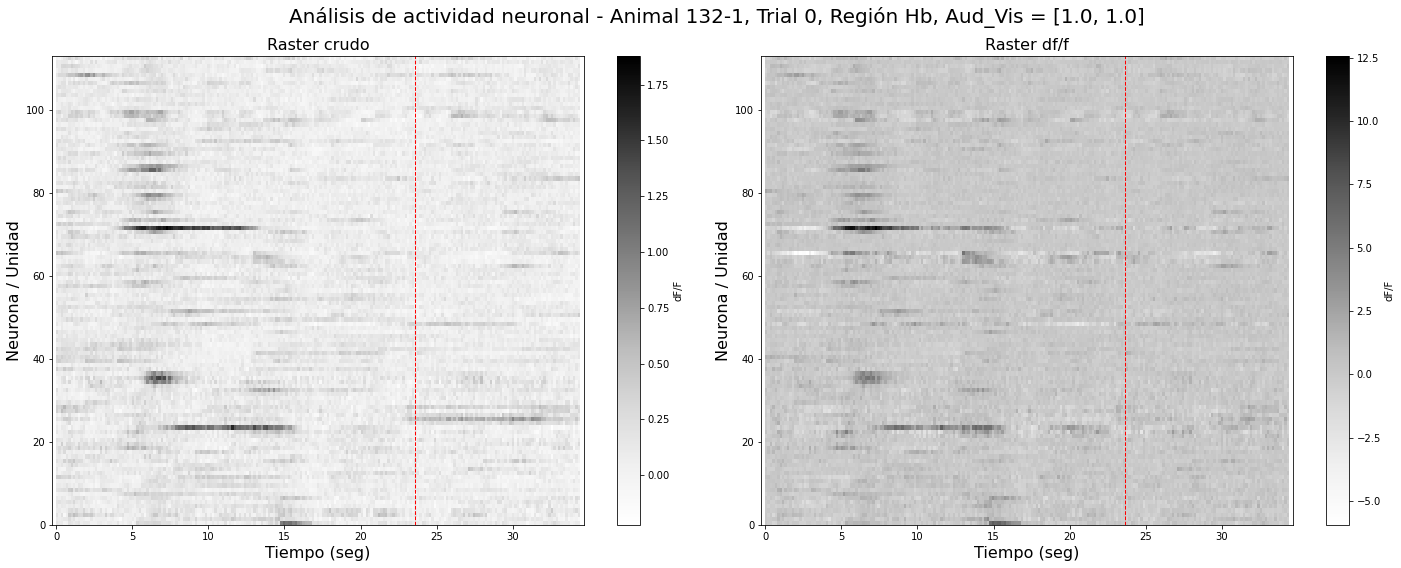

In [15]:
key= '132-1'
region = 'Hb'
trial = 0
if type(trial) == int:
    trials_to_plot = [trial]
else:
    trials_to_plot = range(len(areas[key].trials))
for trial in trials_to_plot:
    t_tot = round(areas[key].trials[trial].total_time,2)
    aud_vis = [areas[key].trials[trial].aud, float(areas[key].trials[trial].vis)]
    roi_activity =  areas[key].trials_rea[trial].roi_dffs_rea[region]


    dffs = areas[key].trials[trial].roi_dffs[region]



    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'Análisis de actividad neuronal - Animal {key}, Trial {trial}, Región {region}, Aud_Vis = {aud_vis}', fontsize=20)

    # Raster plot data cruda
    ax1 = axes[0]
    im = ax1.imshow(roi_activity, aspect='auto', cmap='Greys', interpolation='nearest',
                    extent=[0, t_tot, 0, roi_activity.shape[0]])
    fig.colorbar(im, ax=ax1, label='dF/F')
    ax1.set_xlabel('Tiempo (seg)', fontsize=16)
    ax1.set_ylabel('Neurona / Unidad', fontsize=16)
    ax1.set_title('Raster crudo', fontsize=16)
    ax1.set_xlim(-.25, t_tot+.25)
    ax1.axvline(x=23.6, color='red', linestyle='--', linewidth=1)  # línea punteada roja

    # Raster plot df/f
    ax2 = axes[1]
    im = ax2.imshow(dffs, aspect='auto', cmap='Greys', interpolation='nearest',
                    extent=[0, t_tot, 0, dffs.shape[0]])
    fig.colorbar(im, ax=ax2, label='dF/F')
    ax2.set_xlabel('Tiempo (seg)', fontsize=16)
    ax2.set_ylabel('Neurona / Unidad', fontsize=16)
    ax2.set_title('Raster df/f', fontsize=16)
    ax2.set_xlim(-.25, t_tot+.25)
    ax2.axvline(x=23.6, color='red', linestyle='--', linewidth=1)  # línea punteada roja

    plt.tight_layout()
    plt.show()



[G1 (6–8 dpf)] Ventana 23.6–24.6s  C=nan  AV=nan  Δ(AV−C)=nan
[G2 (12–13 dpf)] Ventana 23.6–24.6s  C=nan  AV=nan  Δ(AV−C)=nan
[G3 (15–16 dpf)] Ventana 23.6–24.6s  C=nan  AV=nan  Δ(AV−C)=nan


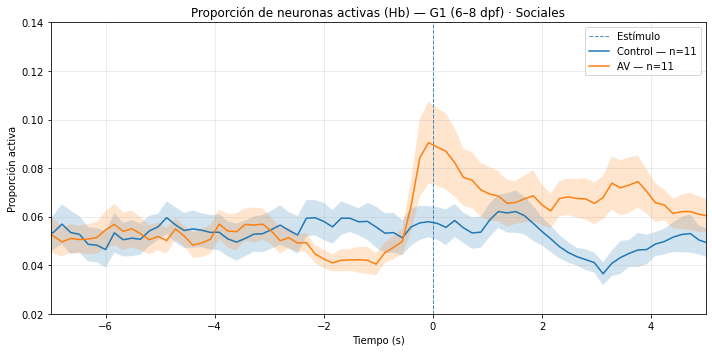

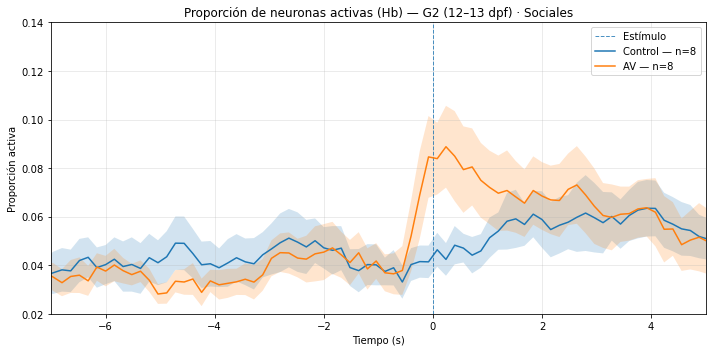

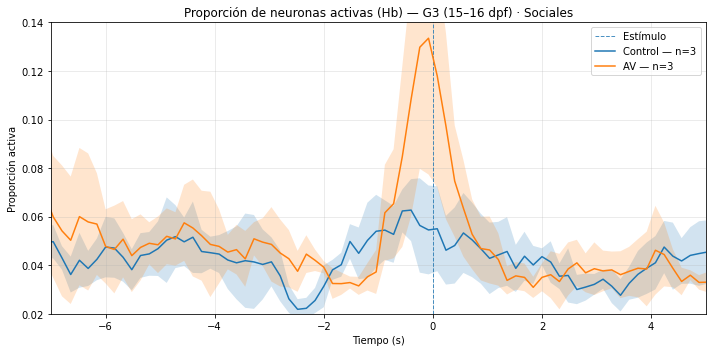

In [64]:
# === Parámetros que TENÉS que ajustar ==============================
region_key = 'Hb'
stim_s     = 23.6         # segundo del estímulo
win_s      = 1.0          # ventana post-estímulo (s)
fps        = 10.0         # <-- PONÉ TU FPS AQUÍ (float). Requerido si no hay trial.frame_times

# Grupos por edad (dpf)
grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
}

# === Utilidades ====================================================
os.chdir(f'H:\My Drive\Valen Agulló\SAN 2025')

def _get_condition(trial):
    return 'AV' if getattr(trial, 'vis', 0) == 1 and getattr(trial, 'aud', 0) == 1 else 'C'

def _trial_timebase(trial, fallback_fps, lefty=None):
    """
    Devuelve vector de tiempos (s) y fps para un trial.
    Usa trial.frame_times si existe; si no, usa trial.fps o fallback_fps.
    """
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft, dtype=float)
        if len(ft) > 1:
            dif = np.diff(ft)
            fps_est = 1.0 / np.median(dif)
        else:
            fps_est = fallback_fps
        return ft, fps_est

    t_fps = getattr(trial, 'fps', None)
    if t_fps is None:
        if fallback_fps is None:
            raise ValueError("Definí 'fps' o prové trial.frame_times / trial.fps.")
        t_fps = fallback_fps

    # rb = getattr(trial, 'roi_binaries', None)
    if lefty==True:
        rb = trial[areas['131-1'].roi_lefties[region_key]]
    rb = getattr(trial, 'roi_binaries_rea', None)
    if rb is None or region_key not in rb:
        raise ValueError(f"Falta roi_binaries_rea['{region_key}'].")
    arr = np.asarray(rb[region_key])            # forma garantizada: (n_rois, n_frames)
    n_frames = arr.shape[1]
    t = np.arange(n_frames, dtype=float) / float(t_fps)
    return t, float(t_fps)

def _prop_active_per_frame(trial):
    """Proporción de neuronas activas (n_rois x n_frames → 1 x n_frames)."""
    rb = getattr(trial, 'roi_binaries_rea', None)
    if rb is None or region_key not in rb:
        return None
    arr = np.asarray(rb[region_key])            # SIEMPRE (n_rois, n_frames)
    arr_bin = (arr > 0).astype(float)
    return arr_bin.mean(axis=0)

def _truncate_to_common_length(list_of_arrays):
    L = [len(a) for a in list_of_arrays if a is not None]
    if not L:
        return [], 0
    m = min(L)
    return [a[:m] for a in list_of_arrays if a is not None], m

def _mean_sem_over_animals(animal_traces):
    if len(animal_traces) == 0:
        return None, None
    X, L = _truncate_to_common_length(animal_traces)
    if L == 0:
        return None, None
    M = np.vstack(X)
    mean = M.mean(axis=0)
    sem  = M.std(axis=0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0] > 1 else np.zeros_like(mean)
    return mean, sem

def _window_indices(t, t0, dur):
    return (t >= t0) & (t < t0 + dur)

# === Procesamiento: solo animales sociales =========================
social_keys = [k for k, a in areas.items() if getattr(a, 'aislado', 1) == 0]

resultados = {g: {"C": {"animals": [], "t": None}, "AV": {"animals": [], "t": None}}
              for g in grupos.keys()}

for k in social_keys:
    area = areas[k]
    edad = int(getattr(area, 'edad', -999))

    # Asignar grupo por edad
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    per_trial = {"C": [], "AV": []}
    per_time  = {"C": [], "AV": []}

    for tr in getattr(area, 'trials_rea', []):
        cond = _get_condition(tr)
        try:
            t, tr_fps = _trial_timebase(tr, fps)
            prop = _prop_active_per_frame(tr)
            if prop is None:
                continue
            m = min(len(t), len(prop))
            per_trial[cond].append(prop[:m])
            per_time[cond].append(t[:m])
        except Exception:
            continue

    # Promedio por animal y condición
    for cond in ['C', 'AV']:
        if len(per_trial[cond]) == 0:
            continue
        series, m = _truncate_to_common_length(per_trial[cond])
        if m == 0:
            continue
        tseries, _ = _truncate_to_common_length(per_time[cond])
        t_common = tseries[0] if len(tseries) > 0 else np.arange(m) / (tr_fps if fps is None else fps)
        animal_mean = np.vstack(series).mean(axis=0)

        resultados[gname][cond]["animals"].append(animal_mean)
        if resultados[gname][cond]["t"] is None:
            resultados[gname][cond]["t"] = t_common

# === Gráficos (3 figuras: G1, G2, G3) =============================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    # Base temporal para graficar
    tC = data['C']["t"]
    tA = data['AV']["t"]
    if mean_AV is not None:
        t_plot = tA[:len(mean_AV)] - stim_s
    elif mean_C is not None:
        t_plot = tC[:len(mean_C)] - stim_s
    else:
        print(f"[{gname}] Sin datos.")
        continue

    w_idx = _window_indices(t_plot, stim_s, win_s)
    def _avg_win(x): return float(np.nanmean(x[w_idx])) if (x is not None and w_idx.any()) else np.nan
    avgC = _avg_win(mean_C) if mean_C is not None else np.nan
    avgA = _avg_win(mean_AV) if mean_AV is not None else np.nan
    delta = (avgA - avgC) if (not np.isnan(avgA) and not np.isnan(avgC)) else np.nan

    fig = plt.figure(figsize=(10, 5))
    plt.title(f"Proporción de neuronas activas (Hb) — {gname} · Sociales")
    if w_idx.any():
        plt.axvspan(t_plot[w_idx][0], t_plot[w_idx][-1], alpha=0.15, label=f"Ventana {win_s:.1f}s")
    plt.axvline(0, linestyle='--', linewidth=1, alpha=0.8, label="Estímulo")

    if mean_C is not None:
        plt.plot(t_plot, mean_C[:len(t_plot)], label=f"Control — n={len(data['C']['animals'])}")
        if sem_C is not None:
            m = min(len(t_plot), len(sem_C))
            plt.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m], alpha=0.2)

    if mean_AV is not None:
        plt.plot(t_plot, mean_AV[:len(t_plot)], label=f"AV — n={len(data['AV']['animals'])}")
        if sem_AV is not None:
            m = min(len(t_plot), len(sem_AV))
            plt.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m], alpha=0.2)

    plt.xlabel("Tiempo (s)")
    plt.ylabel("Proporción activa")
    plt.ylim(.02, .14)
    plt.xlim(-7,5, 7.5)
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
    fig.patch.set_facecolor('white')
    # plt.savefig(f'{gname}_Sociales.png', dpi=300, bbox_inches='tight')

    print(f"[{gname}] Ventana {stim_s:.1f}–{stim_s+win_s:.1f}s  C={avgC:.4f}  AV={avgA:.4f}  Δ(AV−C)={delta:.4f}")


In [26]:
def to_dffs(activities, acts_to_filter, time_scale_in_frames = 15, window = 10, fast = False):
    baseline = linearly_extended_filter(acts_to_filter, time_scale_in_frames, window = window, fast = fast)
    #baseline = gaussian_filter1d(activities, time_scale_in_frames, mode = 'nearest')
    
    dffs = (activities - baseline)#/baseline
    return dffs, baseline

dffs_scale_seconds = 4
dffs_window_seconds = 3

binaries_std_s = 1
binaries_window_seconds = 15

binaries_baseline = 15
binaries_th = 1.5




for key in areas:
    if '52' not in key:
        print(key)
        for trial in areas[key].trials_rea:
            trial.roi_dffs_rea2 = {}
            trial.roi_baselines_rea2 = {}
            trial.roi_binaries_rea2 = {}
            trial.roi_smooth_dffs_rea2 = {}
            if np.isnan(trial.total_time):
                frames_per_s = trial.nframes /37
            else:
                frames_per_s = trial.nframes / trial.total_time
            
            for subarea in trial.roi_binaries_rea:
                
                new_acts = []
                
                for roi in range(trial.roi_binaries_rea[subarea].shape[0]):
                    x = np.arange(len(trial.roi_binaries_rea[subarea][roi]))[trial.roi_binaries_rea[subarea][roi]==0]
                    y = trial.roi_activities[subarea][roi,trial.roi_binaries_rea[subarea][roi]==0]
                    
                    nx = np.arange(trial.nframes)
                    ny = np.interp(nx,x,y)
                    
                    new_acts.append(ny)
                
                new_acts = np.vstack(new_acts)
                
                trial.roi_dffs[subarea], __ = to_dffs(trial.roi_activities[subarea], new_acts, time_scale_in_frames = frames_per_s * dffs_scale_seconds,
                                                                window = int(frames_per_s * dffs_window_seconds), fast = True)
                trial.roi_binaries_rea2[subarea], trial.roi_smooth_dffs_rea2[subarea] = to_binaries(trial.roi_dffs[subarea])
                
           

113-1
114-1
115-1
116-1
117-1
118-1
120-1
121-1
122-1
123-1
124-1
125-1
126-1
127-1
129-1
130-1
131-1
132-1
133-1
134-1
135-1
136-1
137-1
138-1
139-1
143-1


[G1 (6–8 dpf)] Ventana 23.6–24.6s  C=nan  AV=nan  Δ(AV−C)=nan
[G2 (12–13 dpf)] Ventana 23.6–24.6s  C=nan  AV=nan  Δ(AV−C)=nan
[G3 (15–16 dpf)] Ventana 23.6–24.6s  C=nan  AV=nan  Δ(AV−C)=nan


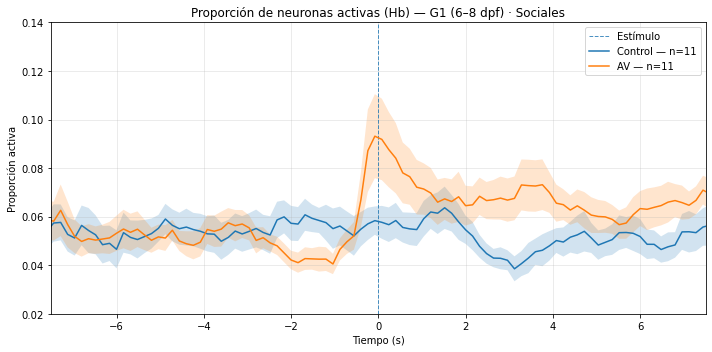

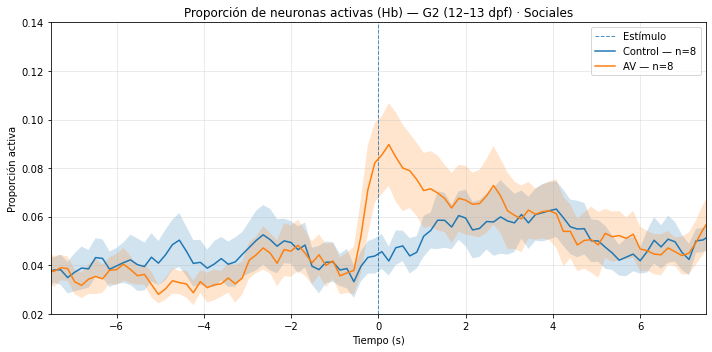

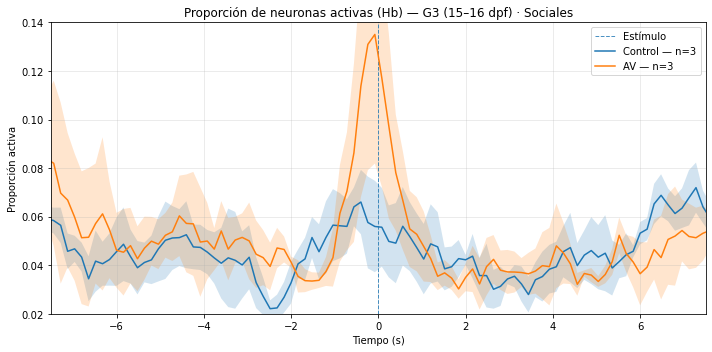

In [144]:
# === Parámetros que TENÉS que ajustar ==============================
region_key = 'Hb'
stim_s     = 23.6         # segundo del estímulo
win_s      = 1.0          # ventana post-estímulo (s)
fps        = 10.0         # <-- PONÉ TU FPS AQUÍ (float). Requerido si no hay trial.frame_times

# Grupos por edad (dpf)
grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
}

# === Utilidades ====================================================
os.chdir(f'H:\My Drive\Valen Agulló\SAN 2025')

def _get_condition(trial):
    return 'AV' if getattr(trial, 'vis', 0) == 1 and getattr(trial, 'aud', 0) == 1 else 'C'

def _trial_timebase(trial, fallback_fps, lefty=None):
    """
    Devuelve vector de tiempos (s) y fps para un trial.
    Usa trial.frame_times si existe; si no, usa trial.fps o fallback_fps.
    """
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft, dtype=float)
        if len(ft) > 1:
            dif = np.diff(ft)
            fps_est = 1.0 / np.median(dif)
        else:
            fps_est = fallback_fps
        return ft, fps_est

    t_fps = getattr(trial, 'fps', None)
    if t_fps is None:
        if fallback_fps is None:
            raise ValueError("Definí 'fps' o prové trial.frame_times / trial.fps.")
        t_fps = fallback_fps

    # rb = getattr(trial, 'roi_binaries', None)
    if lefty==True:
        rb = trial[areas['131-1'].roi_lefties[region_key]]
    rb = getattr(trial, 'roi_binaries_rea2', None)
    if rb is None or region_key not in rb:
        raise ValueError(f"Falta roi_binaries_rea['{region_key}'].")
    arr = np.asarray(rb[region_key])            # forma garantizada: (n_rois, n_frames)
    n_frames = arr.shape[1]
    t = np.arange(n_frames, dtype=float) / float(t_fps)
    return t, float(t_fps)

def _prop_active_per_frame(trial):
    """Proporción de neuronas activas (n_rois x n_frames → 1 x n_frames)."""
    rb = getattr(trial, 'roi_binaries_rea2', None)
    if rb is None or region_key not in rb:
        return None
    arr = np.asarray(rb[region_key])            # SIEMPRE (n_rois, n_frames)
    arr_bin = (arr > 0).astype(float)
    return arr_bin.mean(axis=0)

def _truncate_to_common_length(list_of_arrays):
    L = [len(a) for a in list_of_arrays if a is not None]
    if not L:
        return [], 0
    m = min(L)
    return [a[:m] for a in list_of_arrays if a is not None], m

def _mean_sem_over_animals(animal_traces):
    if len(animal_traces) == 0:
        return None, None
    X, L = _truncate_to_common_length(animal_traces)
    if L == 0:
        return None, None
    M = np.vstack(X)
    mean = M.mean(axis=0)
    sem  = M.std(axis=0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0] > 1 else np.zeros_like(mean)
    return mean, sem

def _window_indices(t, t0, dur):
    return (t >= t0) & (t < t0 + dur)

# === Procesamiento: solo animales sociales =========================
social_keys = [k for k, a in areas.items() if getattr(a, 'aislado', 1) == 0]

resultados = {g: {"C": {"animals": [], "t": None}, "AV": {"animals": [], "t": None}}
              for g in grupos.keys()}

for k in social_keys:
    area = areas[k]
    edad = int(getattr(area, 'edad', -999))

    # Asignar grupo por edad
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    per_trial = {"C": [], "AV": []}
    per_time  = {"C": [], "AV": []}

    for tr in getattr(area, 'trials_rea', []):
        cond = _get_condition(tr)
        try:
            t, tr_fps = _trial_timebase(tr, fps)
            prop = _prop_active_per_frame(tr)
            if prop is None:
                continue
            m = min(len(t), len(prop))
            per_trial[cond].append(prop[:m])
            per_time[cond].append(t[:m])
        except Exception:
            continue

    # Promedio por animal y condición
    for cond in ['C', 'AV']:
        if len(per_trial[cond]) == 0:
            continue
        series, m = _truncate_to_common_length(per_trial[cond])
        if m == 0:
            continue
        tseries, _ = _truncate_to_common_length(per_time[cond])
        t_common = tseries[0] if len(tseries) > 0 else np.arange(m) / (tr_fps if fps is None else fps)
        animal_mean = np.vstack(series).mean(axis=0)

        resultados[gname][cond]["animals"].append(animal_mean)
        if resultados[gname][cond]["t"] is None:
            resultados[gname][cond]["t"] = t_common

# === Gráficos (3 figuras: G1, G2, G3) =============================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    # Base temporal para graficar
    tC = data['C']["t"]
    tA = data['AV']["t"]
    if mean_AV is not None:
        t_plot = tA[:len(mean_AV)]-stim_s
    elif mean_C is not None:
        t_plot = tC[:len(mean_C)]-stim_s
    else:
        print(f"[{gname}] Sin datos.")
        continue

    w_idx = _window_indices(t_plot, stim_s, win_s)
    def _avg_win(x): return float(np.nanmean(x[w_idx])) if (x is not None and w_idx.any()) else np.nan
    avgC = _avg_win(mean_C) if mean_C is not None else np.nan
    avgA = _avg_win(mean_AV) if mean_AV is not None else np.nan
    delta = (avgA - avgC) if (not np.isnan(avgA) and not np.isnan(avgC)) else np.nan

    fig = plt.figure(figsize=(10, 5))
    plt.title(f"Proporción de neuronas activas (Hb) — {gname} · Sociales")
    if w_idx.any():
        plt.axvspan(t_plot[w_idx][0], t_plot[w_idx][-1], alpha=0.15, label=f"Ventana {win_s:.1f}s")
    plt.axvline(0, linestyle='--', linewidth=1, alpha=0.8, label="Estímulo")

    if mean_C is not None:
        plt.plot(t_plot, mean_C[:len(t_plot)], label=f"Control — n={len(data['C']['animals'])}")
        if sem_C is not None:
            m = min(len(t_plot), len(sem_C))
            plt.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m], alpha=0.2)

    if mean_AV is not None:
        plt.plot(t_plot, mean_AV[:len(t_plot)], label=f"AV — n={len(data['AV']['animals'])}")
        if sem_AV is not None:
            m = min(len(t_plot), len(sem_AV))
            plt.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m], alpha=0.2)

    plt.xlabel("Tiempo (s)")
    plt.ylabel("Proporción activa")
    plt.ylim(.02, .14)
    plt.xlim(-7.5, 7.5)
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
    fig.patch.set_facecolor('white')
    # plt.savefig(f'{gname}_Sociales.png', dpi=300, bbox_inches='tight')

    print(f"[{gname}] Ventana {stim_s:.1f}–{stim_s+win_s:.1f}s  C={avgC:.4f}  AV={avgA:.4f}  Δ(AV−C)={delta:.4f}")


In [145]:
def construir_df(areas, pred_grupo=None, solo_social=True):
    """
    Construye un DataFrame largo con:
    fish_id, roi_id, cond ('C'/'AV'), y (#frames activos en ventana), n_frames (en ventana),
    edad, aislado.
    Si pred_grupo es None, no filtra por edad.
    """
    rows = []
    for fish_id, area in areas.items():
        edad    = int(getattr(area, 'edad', -999))
        aislado = int(getattr(area, 'aislado', 1))
        if solo_social and aislado != 0:
            continue
        if pred_grupo is not None and not pred_grupo(edad):
            continue

        trials = getattr(area, 'trials_rea', [])
        for tr in trials:
            cond = _get_condition(tr)
            try:
                t, _fps = _trial_timebase(tr, fps)
            except Exception:
                continue
            w = _window_mask(t, stim_s, win_s)
            if not w.any():
                continue

            rb = getattr(tr, 'roi_binaries_rea', None)
            if rb is None or region_key not in rb:
                continue
            B = np.asarray(rb[region_key])  # (n_rois, n_frames)
            if B.ndim != 2:
                continue
            B = (B > 0).astype(np.uint8)
            n_rois = B.shape[0]
            y_vec = B[:, w].sum(axis=1)                # éxitos (frames activos) por neurona
            n_vec = np.full(n_rois, int(w.sum()))      # total de frames en ventana

            for roi_idx in range(n_rois):
                rows.append({
                    "fish_id":   str(fish_id),
                    "roi_id":    int(roi_idx),
                    "cond":      cond,
                    "y":         int(y_vec[roi_idx]),
                    "n_frames":  int(n_vec[roi_idx]),
                    "edad":      edad,
                    "aislado":   aislado
                })
    return pd.DataFrame(rows)


def _window_mask(t, t0, dur):
    """Máscara booleana para [t0, t0+dur)."""
    return (t >= t0) & (t < t0 + dur)



In [146]:

import statsmodels.api as sm

def ajustar_glm_binomial_cluster(df):
    df = df.copy()
    df['prop'] = df['y'] / df['n_frames']
    df['isAV'] = (df['cond'] == 'AV').astype(int)

    # Diseñador con nombres de columnas:
    X = sm.add_constant(df[['isAV']], has_constant='add')  # columnas: ['const','isAV']
    y = df['prop'].values
    w = df['n_frames'].astype(float).values

    # cluster = neurona (pez + "_" + roi)
    clusters = (df['fish_id'].astype(str) + "_" + df['roi_id'].astype(str)).values

    glm = sm.GLM(y, X, family=sm.families.Binomial(), freq_weights=w)
    fit = glm.fit(cov_type='cluster', cov_kwds={'groups': clusters})

    beta_av = float(fit.params['isAV'])
    se_av   = float(fit.bse['isAV'])
    z       = float(fit.tvalues['isAV'])  # con cov robusta, t ≈ z
    p_two   = float(fit.pvalues['isAV'])  # <-- usá p directamente del modelo

    OR      = np.exp(beta_av)
    lo, hi  = beta_av - 1.96*se_av, beta_av + 1.96*se_av

    return {
        "beta_av": beta_av,
        "se_av":   se_av,
        "z":       z,
        "p_two":   p_two,
        "OR":      OR,
        "OR_lo":   float(np.exp(lo)),
        "OR_hi":   float(np.exp(hi)),
        "result":  fit
    }


In [147]:
# === Inferencia: GLM Binomial con SEs robustos por neurona (cluster) ===
# Requiere: df_g con columnas ['y','n_frames','cond','fish_id','roi_id']


# === Correr por grupo (sociales) y combinado ===
solo_social = True
grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
}

def construir_df_simple(grupo_pred=None):
    df_g = construir_df(areas, pred_grupo=grupo_pred, solo_social=solo_social)
    # aseguramos que haya ambas condiciones
    if len(df_g)==0 or df_g['cond'].nunique()<2:
        return None
    return df_g

res_glm = {}

for gname, gpred in grupos.items():
    df_g = construir_df_simple(gpred)
    if df_g is None:
        print(f"[{gname}] Sin datos suficientes.")
        continue
    res = ajustar_glm_binomial_cluster(df_g)
    res_glm[gname] = res
    print(f"\n=== {gname} · Sociales={solo_social} ===")
    print(f"filas={len(df_g)}, peces={df_g['fish_id'].nunique()}, neuronas={(df_g['fish_id'].astype(str)+'_'+df_g['roi_id'].astype(str)).nunique()}")
    print(f"Efecto AV (log-odds): {res['beta_av']:.4f} ± {res['se_av']:.4f} [z={res['z']:.2f}, p={res['p_two']:.3g}]")
    print(f"OR={res['OR']:.3f}  IC95% OR=[{res['OR_lo']:.3f}, {res['OR_hi']:.3f}]")

# Combinado (todos los grupos etarios)
df_all = construir_df_simple(None)
if df_all is not None:
    res_all = ajustar_glm_binomial_cluster(df_all)
    res_glm["Todos"] = res_all
    print(f"\n=== Todos (combinado) · Sociales={solo_social} ===")
    print(f"filas={len(df_all)}, peces={df_all['fish_id'].nunique()}, neuronas={(df_all['fish_id'].astype(str)+'_'+df_all['roi_id'].astype(str)).nunique()}")
    print(f"Efecto AV (log-odds): {res_all['beta_av']:.4f} ± {res_all['se_av']:.4f} [z={res_all['z']:.2f}, p={res_all['p_two']:.3g}]")
    print(f"OR={res_all['OR']:.3f}  IC95% OR=[{res_all['OR_lo']:.3f}, {res_all['OR_hi']:.3f}]")
else:
    print("\n[Todos] Sin datos suficientes.")


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)
c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)



=== G1 (6–8 dpf) · Sociales=True ===
filas=14090, peces=11, neuronas=1409
Efecto AV (log-odds): 0.3120 ± 0.0636 [z=4.91, p=9.15e-07]
OR=1.366  IC95% OR=[1.206, 1.547]

=== G2 (12–13 dpf) · Sociales=True ===
filas=9390, peces=8, neuronas=939
Efecto AV (log-odds): 0.6835 ± 0.0824 [z=8.29, p=1.12e-16]
OR=1.981  IC95% OR=[1.685, 2.328]


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)



=== G3 (15–16 dpf) · Sociales=True ===
filas=3310, peces=3, neuronas=331
Efecto AV (log-odds): 0.3903 ± 0.1363 [z=2.86, p=0.00419]
OR=1.477  IC95% OR=[1.131, 1.930]

=== Todos (combinado) · Sociales=True ===
filas=26790, peces=22, neuronas=2679
Efecto AV (log-odds): 0.4507 ± 0.0474 [z=9.51, p=1.95e-21]
OR=1.569  IC95% OR=[1.430, 1.722]


c:\Users\PC\anaconda3\envs\PKLS\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1530: SpecificationWarning: cov_type not fully supported with freq_weights
  SpecificationWarning)


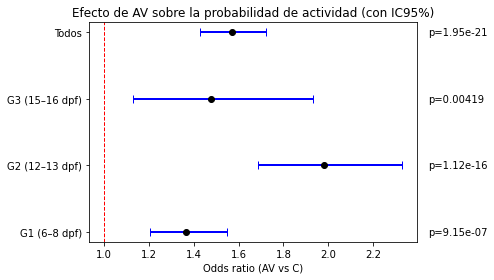

In [148]:
import matplotlib.pyplot as plt

# Orden de los grupos
order = ["G1 (6–8 dpf)", "G2 (12–13 dpf)", "G3 (15–16 dpf)", "Todos"]

# Extraigo los resultados en listas
labels, ors, lo, hi, pvals = [], [], [], [], []
for g in order:
    if g in res_glm:
        labels.append(g)
        ors.append(res_glm[g]["OR"])
        lo.append(res_glm[g]["OR_lo"])
        hi.append(res_glm[g]["OR_hi"])
        pvals.append(res_glm[g]["p_two"])

# Plot tipo forest plot
fig, ax = plt.subplots(figsize=(7,4))

y_pos = range(len(labels))
ax.errorbar(ors, y_pos, xerr=[np.array(ors)-np.array(lo), np.array(hi)-np.array(ors)],
            fmt='o', color='black', ecolor='blue', elinewidth=2, capsize=4)

# Línea de referencia en OR=1 (sin efecto)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel("Odds ratio (AV vs C)")
ax.set_title("Efecto de AV sobre la probabilidad de actividad (con IC95%)")

# Agrego los p-valores a la derecha
for y, or_, p in zip(y_pos, ors, pvals):
    ax.text(max(hi)*1.05, y, f"p={p:.3g}", va='center')

plt.tight_layout()
fig.patch.set_facecolor('white')
# plt.savefig(f'Prob_act_AV.png', dpi=300, bbox_inches='tight')
plt.show()


[G1 (6–8 dpf)] Ventana 23.6–24.6s  C=0.0495  AV=0.0668  Δ(AV−C)=0.0172
[G2 (12–13 dpf)] Ventana 23.6–24.6s  C=0.0465  AV=0.0793  Δ(AV−C)=0.0329
[G3 (15–16 dpf)] Ventana 23.6–24.6s  C=0.0471  AV=0.0594  Δ(AV−C)=0.0123


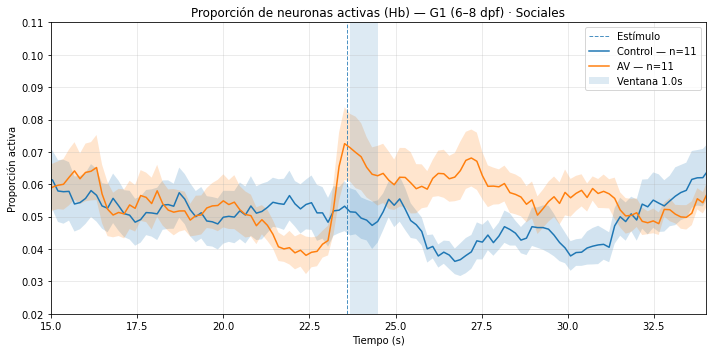

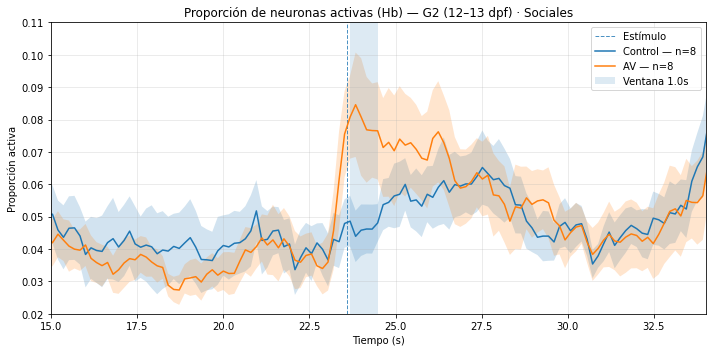

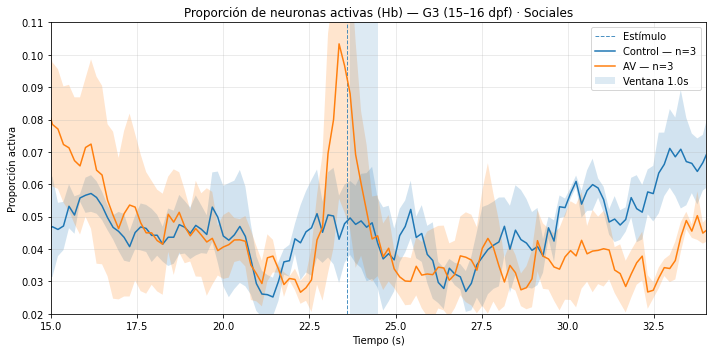

In [141]:
# === Parámetros que TENÉS que ajustar ==============================
region_key = 'Hb'
stim_s     = 23.6         # segundo del estímulo
win_s      = 1.0          # ventana post-estímulo (s)
fps        = 10.0         # <-- PONÉ TU FPS AQUÍ (float). Requerido si no hay trial.frame_times

# Grupos por edad (dpf)
grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
}

# === Utilidades ====================================================
os.chdir(f'H:\My Drive\Valen Agulló\SAN 2025')

def _get_condition(trial):
    return 'AV' if getattr(trial, 'vis', 0) == 1 and getattr(trial, 'aud', 0) == 1 else 'C'

def _trial_timebase(trial, fallback_fps, lefty=None):
    """
    Devuelve vector de tiempos (s) y fps para un trial.
    Usa trial.frame_times si existe; si no, usa trial.fps o fallback_fps.
    """
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft, dtype=float)
        if len(ft) > 1:
            dif = np.diff(ft)
            fps_est = 1.0 / np.median(dif)
        else:
            fps_est = fallback_fps
        return ft, fps_est

    t_fps = getattr(trial, 'fps', None)
    if t_fps is None:
        if fallback_fps is None:
            raise ValueError("Definí 'fps' o proveé trial.frame_times / trial.fps.")
        t_fps = fallback_fps

    # rb = getattr(trial, 'roi_binaries', None)
    if lefty==True:
        rb = trial[areas['131-1'].roi_lefties[region_key]]
    rb = getattr(trial, 'roi_binaries', None)
    if rb is None or region_key not in rb:
        raise ValueError(f"Falta roi_binaries['{region_key}'].")
    arr = np.asarray(rb[region_key])            # forma garantizada: (n_rois, n_frames)
    n_frames = arr.shape[1]
    t = np.arange(n_frames, dtype=float) / float(t_fps)
    return t, float(t_fps)

def _prop_active_per_frame(trial):
    """Proporción de neuronas activas (n_rois x n_frames → 1 x n_frames)."""
    rb = getattr(trial, 'roi_binaries', None)
    if rb is None or region_key not in rb:
        return None
    arr = np.asarray(rb[region_key])            # SIEMPRE (n_rois, n_frames)
    arr_bin = (arr > 0).astype(float)
    return arr_bin.mean(axis=0)

def _truncate_to_common_length(list_of_arrays):
    L = [len(a) for a in list_of_arrays if a is not None]
    if not L:
        return [], 0
    m = min(L)
    return [a[:m] for a in list_of_arrays if a is not None], m

def _mean_sem_over_animals(animal_traces):
    if len(animal_traces) == 0:
        return None, None
    X, L = _truncate_to_common_length(animal_traces)
    if L == 0:
        return None, None
    M = np.vstack(X)
    mean = M.mean(axis=0)
    sem  = M.std(axis=0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0] > 1 else np.zeros_like(mean)
    return mean, sem

def _window_indices(t, t0, dur):
    return (t >= t0) & (t < t0 + dur)

# === Procesamiento: solo animales sociales =========================
social_keys = [k for k, a in areas.items() if getattr(a, 'aislado', 1) == 0]

resultados = {g: {"C": {"animals": [], "t": None}, "AV": {"animals": [], "t": None}}
              for g in grupos.keys()}

for k in social_keys:
    area = areas[k]
    edad = int(getattr(area, 'edad', -999))

    # Asignar grupo por edad
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    per_trial = {"C": [], "AV": []}
    per_time  = {"C": [], "AV": []}

    for tr in getattr(area, 'trials', []):
        cond = _get_condition(tr)
        try:
            t, tr_fps = _trial_timebase(tr, fps)
            prop = _prop_active_per_frame(tr)
            if prop is None:
                continue
            m = min(len(t), len(prop))
            per_trial[cond].append(prop[:m])
            per_time[cond].append(t[:m])
        except Exception:
            continue

    # Promedio por animal y condición
    for cond in ['C', 'AV']:
        if len(per_trial[cond]) == 0:
            continue
        series, m = _truncate_to_common_length(per_trial[cond])
        if m == 0:
            continue
        tseries, _ = _truncate_to_common_length(per_time[cond])
        t_common = tseries[0] if len(tseries) > 0 else np.arange(m) / (tr_fps if fps is None else fps)
        animal_mean = np.vstack(series).mean(axis=0)

        resultados[gname][cond]["animals"].append(animal_mean)
        if resultados[gname][cond]["t"] is None:
            resultados[gname][cond]["t"] = t_common

# === Gráficos (3 figuras: G1, G2, G3) =============================
for gname in grupos.keys():
    data = resultados[gname]
    mean_C, sem_C   = _mean_sem_over_animals(data['C']["animals"])
    mean_AV, sem_AV = _mean_sem_over_animals(data['AV']["animals"])

    # Base temporal para graficar
    tC = data['C']["t"]
    tA = data['AV']["t"]
    if mean_AV is not None:
        t_plot = tA[:len(mean_AV)]
    elif mean_C is not None:
        t_plot = tC[:len(mean_C)]
    else:
        print(f"[{gname}] Sin datos.")
        continue

    w_idx = _window_indices(t_plot, stim_s, win_s)
    def _avg_win(x): return float(np.nanmean(x[w_idx])) if (x is not None and w_idx.any()) else np.nan
    avgC = _avg_win(mean_C) if mean_C is not None else np.nan
    avgA = _avg_win(mean_AV) if mean_AV is not None else np.nan
    delta = (avgA - avgC) if (not np.isnan(avgA) and not np.isnan(avgC)) else np.nan

    fig = plt.figure(figsize=(10, 5))
    plt.title(f"Proporción de neuronas activas (Hb) — {gname} · Sociales")
    if w_idx.any():
        plt.axvspan(t_plot[w_idx][0], t_plot[w_idx][-1], alpha=0.15, label=f"Ventana {win_s:.1f}s")
    plt.axvline(stim_s, linestyle='--', linewidth=1, alpha=0.8, label="Estímulo")

    if mean_C is not None:
        plt.plot(t_plot, mean_C[:len(t_plot)], label=f"Control — n={len(data['C']['animals'])}")
        if sem_C is not None:
            m = min(len(t_plot), len(sem_C))
            plt.fill_between(t_plot[:m], mean_C[:m]-sem_C[:m], mean_C[:m]+sem_C[:m], alpha=0.2)

    if mean_AV is not None:
        plt.plot(t_plot, mean_AV[:len(t_plot)], label=f"AV — n={len(data['AV']['animals'])}")
        if sem_AV is not None:
            m = min(len(t_plot), len(sem_AV))
            plt.fill_between(t_plot[:m], mean_AV[:m]-sem_AV[:m], mean_AV[:m]+sem_AV[:m], alpha=0.2)

    plt.xlabel("Tiempo (s)")
    plt.ylabel("Proporción activa")
    plt.ylim(.02, .11)
    plt.xlim(15, 34)
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
    fig.patch.set_facecolor('white')
    # plt.savefig(f'{gname}_Sociales.png', dpi=300, bbox_inches='tight')

    print(f"[{gname}] Ventana {stim_s:.1f}–{stim_s+win_s:.1f}s  C={avgC:.4f}  AV={avgA:.4f}  Δ(AV−C)={delta:.4f}")


G3 (15–16 dpf) Wilcoxon AV vs C: p=0.25
[G1 (6–8 dpf)] Sin datos suficientes.
[G2 (12–13 dpf)] Sin datos suficientes.
[G3 (15–16 dpf)] Sin datos suficientes.

[Todos] Sin datos suficientes.


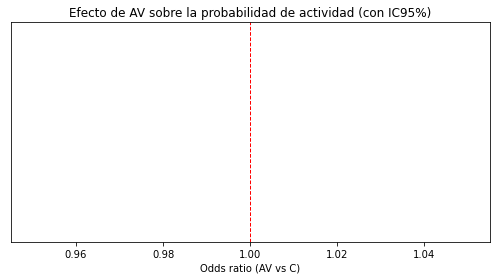

In [149]:
from scipy.stats import wilcoxon

# Para un grupo específico (ejemplo G1):
vals = []
G_ver =list(grupos.keys())[2]
for cond in ['C','AV']:
    # promedios por animal en la ventana
    animals = []
    for trace in resultados[G_ver][cond]['animals']:
        t = resultados[G_ver][cond]['t']
        w = (t >= stim_s) & (t < stim_s+win_s)
        animals.append(trace[w].mean())
    resultados[G_ver][cond]['win_means'] = animals

# Armo pares C y AV por animal (sólo donde hay ambos)
pairs = list(zip(resultados[G_ver]['C']['win_means'],
                 resultados[G_ver]['AV']['win_means']))
pairs = [(c,a) for c,a in pairs if not (np.isnan(c) or np.isnan(a))]
if pairs:
    c_vals, av_vals = zip(*pairs)
    stat, pval = wilcoxon(av_vals, c_vals, alternative='two-sided')
    print(f"{G_ver} Wilcoxon AV vs C: p={pval:.6g}")

import statsmodels.api as sm

def ajustar_glm_binomial_cluster(df):
    df = df.copy()
    df['prop'] = df['y'] / df['n_frames']
    df['isAV'] = (df['cond'] == 'AV').astype(int)

    # Diseñador con nombres de columnas:
    X = sm.add_constant(df[['isAV']], has_constant='add')  # columnas: ['const','isAV']
    y = df['prop'].values
    w = df['n_frames'].astype(float).values

    # cluster = neurona (pez + "_" + roi)
    clusters = (df['fish_id'].astype(str) + "_" + df['roi_id'].astype(str)).values

    glm = sm.GLM(y, X, family=sm.families.Binomial(), freq_weights=w)
    fit = glm.fit(cov_type='cluster', cov_kwds={'groups': clusters})

    beta_av = float(fit.params['isAV'])
    se_av   = float(fit.bse['isAV'])
    z       = float(fit.tvalues['isAV'])  # con cov robusta, t ≈ z
    p_two   = float(fit.pvalues['isAV'])  # <-- usá p directamente del modelo

    OR      = np.exp(beta_av)
    lo, hi  = beta_av - 1.96*se_av, beta_av + 1.96*se_av

    return {
        "beta_av": beta_av,
        "se_av":   se_av,
        "z":       z,
        "p_two":   p_two,
        "OR":      OR,
        "OR_lo":   float(np.exp(lo)),
        "OR_hi":   float(np.exp(hi)),
        "result":  fit
    }

def construir_df(areas, pred_grupo=None, solo_social=True):
    """
    Construye un DataFrame largo con:
    fish_id, roi_id, cond ('C'/'AV'), y (#frames activos en ventana), n_frames (en ventana),
    edad, aislado.
    Si pred_grupo es None, no filtra por edad.
    """
    rows = []
    for fish_id, area in areas.items():
        edad    = int(getattr(area, 'edad', -999))
        aislado = int(getattr(area, 'aislado', 1))
        if solo_social and aislado != 0:
            continue
        if pred_grupo is not None and not pred_grupo(edad):
            continue

        trials = getattr(area, 'trials', [])
        for tr in trials:
            cond = _get_condition(tr)
            try:
                t, _fps = _trial_timebase(tr, fps)
            except Exception:
                continue
            w = _window_mask(t, stim_s, win_s)
            if not w.any():
                continue

            rb = getattr(tr, 'roi_binaries', None)
            if rb is None or region_key not in rb:
                continue
            B = np.asarray(rb[region_key])  # (n_rois, n_frames)
            if B.ndim != 2:
                continue
            B = (B > 0).astype(np.uint8)
            n_rois = B.shape[0]
            y_vec = B[:, w].sum(axis=1)                # éxitos (frames activos) por neurona
            n_vec = np.full(n_rois, int(w.sum()))      # total de frames en ventana

            for roi_idx in range(n_rois):
                rows.append({
                    "fish_id":   str(fish_id),
                    "roi_id":    int(roi_idx),
                    "cond":      cond,
                    "y":         int(y_vec[roi_idx]),
                    "n_frames":  int(n_vec[roi_idx]),
                    "edad":      edad,
                    "aislado":   aislado
                })
    return pd.DataFrame(rows)


def _window_mask(t, t0, dur):
    """Máscara booleana para [t0, t0+dur)."""
    return (t >= t0) & (t < t0 + dur)


# === Inferencia: GLM Binomial con SEs robustos por neurona (cluster) ===
# Requiere: df_g con columnas ['y','n_frames','cond','fish_id','roi_id']


# === Correr por grupo (sociales) y combinado ===
solo_social = True
grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
}

def construir_df_simple(grupo_pred=None):
    df_g = construir_df(areas, pred_grupo=grupo_pred, solo_social=solo_social)
    # aseguramos que haya ambas condiciones
    if len(df_g)==0 or df_g['cond'].nunique()<2:
        return None
    return df_g

res_glm = {}

for gname, gpred in grupos.items():
    df_g = construir_df_simple(gpred)
    if df_g is None:
        print(f"[{gname}] Sin datos suficientes.")
        continue
    res = ajustar_glm_binomial_cluster(df_g)
    res_glm[gname] = res
    print(f"\n=== {gname} · Sociales={solo_social} ===")
    print(f"filas={len(df_g)}, peces={df_g['fish_id'].nunique()}, neuronas={(df_g['fish_id'].astype(str)+'_'+df_g['roi_id'].astype(str)).nunique()}")
    print(f"Efecto AV (log-odds): {res['beta_av']:.4f} ± {res['se_av']:.4f} [z={res['z']:.2f}, p={res['p_two']:.3g}]")
    print(f"OR={res['OR']:.3f}  IC95% OR=[{res['OR_lo']:.3f}, {res['OR_hi']:.3f}]")

# Combinado (todos los grupos etarios)
df_all = construir_df_simple(None)
if df_all is not None:
    res_all = ajustar_glm_binomial_cluster(df_all)
    res_glm["Todos"] = res_all
    print(f"\n=== Todos (combinado) · Sociales={solo_social} ===")
    print(f"filas={len(df_all)}, peces={df_all['fish_id'].nunique()}, neuronas={(df_all['fish_id'].astype(str)+'_'+df_all['roi_id'].astype(str)).nunique()}")
    print(f"Efecto AV (log-odds): {res_all['beta_av']:.4f} ± {res_all['se_av']:.4f} [z={res_all['z']:.2f}, p={res_all['p_two']:.3g}]")
    print(f"OR={res_all['OR']:.3f}  IC95% OR=[{res_all['OR_lo']:.3f}, {res_all['OR_hi']:.3f}]")
else:
    print("\n[Todos] Sin datos suficientes.")

import matplotlib.pyplot as plt

# Orden de los grupos
order = ["G1 (6–8 dpf)", "G2 (12–13 dpf)", "G3 (15–16 dpf)", "Todos"]

# Extraigo los resultados en listas
labels, ors, lo, hi, pvals = [], [], [], [], []
for g in order:
    if g in res_glm:
        labels.append(g)
        ors.append(res_glm[g]["OR"])
        lo.append(res_glm[g]["OR_lo"])
        hi.append(res_glm[g]["OR_hi"])
        pvals.append(res_glm[g]["p_two"])

# Plot tipo forest plot
fig, ax = plt.subplots(figsize=(7,4))

y_pos = range(len(labels))
ax.errorbar(ors, y_pos, xerr=[np.array(ors)-np.array(lo), np.array(hi)-np.array(ors)],
            fmt='o', color='black', ecolor='blue', elinewidth=2, capsize=4)

# Línea de referencia en OR=1 (sin efecto)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel("Odds ratio (AV vs C)")
ax.set_title("Efecto de AV sobre la probabilidad de actividad (con IC95%)")

# Agrego los p-valores a la derecha
for y, or_, p in zip(y_pos, ors, pvals):
    ax.text(max(hi)*1.05, y, f"p={p:.3g}", va='center')

plt.tight_layout()
fig.patch.set_facecolor('white')
# plt.savefig(f'Prob_act_AV.png', dpi=300, bbox_inches='tight')
plt.show()


In [151]:
# Construyo un dataframe largo con columna "grupo"
dfs_prop = []
for gname, gpred in list(grupos.items()) + [("Todos", None)]:
    df_g = construir_df_prop(areas, pred_grupo=gpred, solo_social=solo_social)
    if df_g is None or df_g.empty or df_g['cond'].nunique()<2:
        continue
    df_g = df_g.copy()
    df_g['grupo'] = gname
    dfs_prop.append(df_g)

df_prop_all = pd.concat(dfs_prop, ignore_index=True)


ValueError: No objects to concatenate

In [150]:
summary = (df_prop_all
           .groupby(["grupo"]))

AttributeError: 'list' object has no attribute 'groupby'

In [126]:
import matplotlib.pyplot as plt

# === Resumen por grupo y condición ===
# usamos 'prop' = probabilidad de activarse en la ventana
summary = (df_prop_all
           .groupby(["grupo","cond"])
           .agg(mean_prop=("prop","mean"),
                sem_prop=("prop",lambda x: x.std(ddof=1)/np.sqrt(len(x))))
           .reset_index())

# Orden de grupos
order = ["G1 (6–8 dpf)", "G2 (12–13 dpf)", "G3 (15–16 dpf)", "Todos"]
colors = {"C":"skyblue", "AV":"orange"}

fig, ax = plt.subplots(figsize=(8,5))

for cond in ["C","AV"]:
    sub = summary[summary["cond"]==cond]
    x = [order.index(g) for g in sub["grupo"]]
    ax.errorbar(x, sub["mean_prop"], yerr=sub["sem_prop"],
                fmt='o-', color=colors[cond], label=cond,
                capsize=4, markersize=8)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.set_ylabel("Probabilidad de activación (ventana)")
ax.set_title("Probabilidad de activación por grupo · C vs AV")
ax.legend(title="Condición")
ax.grid(alpha=0.3)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


AttributeError: 'list' object has no attribute 'groupby'

In [159]:
# ================================================================
# Análisis de probabilidad de respuesta con los nuevos datos "rea"


# --------------------------
# Parámetros del análisis
# --------------------------
region_key = "Hb"   # región de interés
stim_s     = 23.6   # tiempo del estímulo en segundos
fps        = 6.5    # cuadros por segundo (usado si no hay frame_times)
post_frames = 6     # número de frames post-estímulo para evaluar
solo_social = True  # filtrar solo animales sociales

# Definición de grupos etarios
grupos = {
    "G1 (6–8 dpf)":   lambda e: 6 <= e <= 8,
    "G2 (12–13 dpf)": lambda e: 12 <= e <= 13,
    "G3 (15–16 dpf)": lambda e: 15 <= e <= 16,
}

# --------------------------
# Funciones auxiliares
# --------------------------

def _get_condition(trial):
    """Devuelve 'AV' si el trial es audiovisual, 'C' si es control."""
    return 'AV' if getattr(trial, 'vis', 0)==1 and getattr(trial, 'aud', 0)==1 else 'C'

def _trial_timebase(trial, fallback_fps):
    """
    Devuelve el vector de tiempos en segundos y el fps estimado.
    Si el trial tiene frame_times los usa, si no recurre a fps conocido.
    """
    ft = getattr(trial, 'frame_times', None)
    if ft is not None:
        ft = np.asarray(ft, float)
        if len(ft) > 1:
            fps_est = 1.0 / np.median(np.diff(ft))
        else:
            fps_est = fallback_fps
        return ft, float(fps_est)
    else:
        t_fps = getattr(trial, 'fps', None) or fallback_fps
        n_frames = np.asarray(trial.roi_binaries_rea[region_key]).shape[1]
        t = np.arange(n_frames, dtype=float) / float(t_fps)
        return t, float(t_fps)

# --------------------------
# Construcción del dataframe
# --------------------------

rows = []

for fish_id, area in areas.items():
    edad    = int(getattr(area, "edad", -999))
    aislado = int(getattr(area, "aislado", 1))

    # Filtramos si solo queremos animales sociales
    if solo_social and aislado != 0:
        continue

    # Determinar grupo etario
    gname = None
    for name, pred in grupos.items():
        if pred(edad):
            gname = name
            break
    if gname is None:
        continue

    # Iterar trials_rea
    for tr in getattr(area, "trials_rea", []):
        cond = _get_condition(tr)

        try:
            t, tr_fps = _trial_timebase(tr, fps)
        except Exception:
            continue

        # Posición del estímulo en frames
        stim_frame = int(round(stim_s * tr_fps))

        # Ventana: los 6 frames post estímulo
        w_idx = np.arange(stim_frame, stim_frame + post_frames)
        if w_idx.max() >= len(t):
            continue  # descartar si la ventana excede el trial

        # Extraer matriz binaria (n_rois × n_frames)
        rb = getattr(tr, "roi_binaries_rea", None)
        if rb is None or region_key not in rb:
            continue

        B = np.asarray(rb[region_key])  # (n_rois, n_frames)
        if B.ndim != 2:
            continue
        B = (B > 0).astype(int)

        # Para cada neurona: 1 si se prendió ≥1 vez en ventana, 0 si no
        y_any = (B[:, w_idx].sum(axis=1) > 0).astype(int)

        for roi_idx, resp in enumerate(y_any):
            rows.append({
                "fish_id": str(fish_id),
                "roi_id": roi_idx,
                "edad": edad,
                "grupo": gname,
                "cond": cond,
                "respuesta": resp
            })

# Convertir a DataFrame
df_resp = pd.DataFrame(rows)

# --------------------------
# Cálculo de probabilidades
# --------------------------

# Probabilidad = promedio de la columna 'respuesta' por grupo-condición
summary = (df_resp
           .groupby(["grupo","cond"])
           .agg(mean_prob=("respuesta","mean"),
                sd_prob=("respuesta","std"),
                n=("respuesta","count"))
           .reset_index())

# Calcular SEM también (opcional)
summary["sem_prob"] = summary["sd_prob"] / np.sqrt(summary["n"])

print(summary)


            grupo cond  mean_prob   sd_prob     n  sem_prob
0    G1 (6–8 dpf)   AV   0.136125  0.342945  7045  0.004086
1    G1 (6–8 dpf)    C   0.109865  0.312744  7045  0.003726
2  G2 (12–13 dpf)   AV   0.178701  0.383142  4695  0.005592
3  G2 (12–13 dpf)    C   0.117785  0.322388  4695  0.004705
4  G3 (15–16 dpf)   AV   0.142598  0.349768  1655  0.008598
5  G3 (15–16 dpf)    C   0.105136  0.306821  1655  0.007542


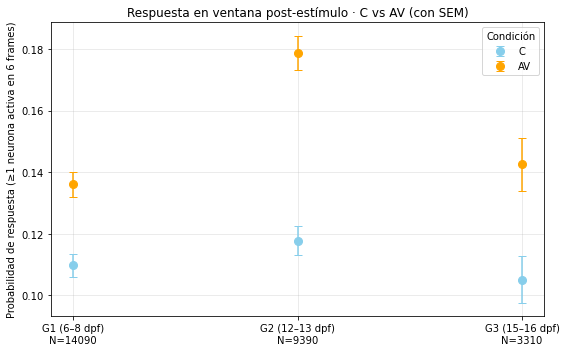

In [160]:
# ================================================================
# Gráfico de probabilidad de respuesta con SEM y N en el eje X
# ================================================================


# --- Resumen (ya armado antes) ---
summary = (df_resp
           .groupby(["grupo","cond"])
           .agg(mean_prob=("respuesta","mean"),
                sd_prob=("respuesta","std"),
                n=("respuesta","count"))
           .reset_index())
summary["sem_prob"] = summary["sd_prob"] / np.sqrt(summary["n"])

# --- Gráfico ---
order = list(grupos.keys())
colors = {"C":"skyblue", "AV":"orange"}

fig, ax = plt.subplots(figsize=(8,5))

for cond in ["C","AV"]:
    sub = summary[summary["cond"]==cond]
    x = [order.index(g) for g in sub["grupo"]]
    ax.errorbar(x, sub["mean_prob"], yerr=sub["sem_prob"],
                fmt='o', color=colors[cond], label=cond,   # 👈 solo puntos
                capsize=4, markersize=8)

# Poner nombres de grupos + N en el eje X
xticks = []
xticklabels = []
for i, g in enumerate(order):
    # Sumar N de C + AV (cantidad total de neuronas en ese grupo)
    n_total = summary.loc[summary["grupo"]==g, "n"].sum()
    xticks.append(i)
    xticklabels.append(f"{g}\nN={n_total}")

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

ax.set_ylabel("Probabilidad de respuesta (≥1 neurona activa en 6 frames)")
ax.set_title("Respuesta en ventana post-estímulo · C vs AV (con SEM)")
ax.legend(title="Condición")
ax.grid(alpha=0.3)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()
